# Visual Tags Overview - April 2026

This notebook provides a comprehensive examination of all visual tags used across the entire corpus. 

**Objective:** Identify every unique visual tag used in the tagging files and analyze their distribution and relationships (co-occurrence network).

In [94]:
import pandas as pd
import os
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Paths
TAGS_FOLDER = '../visual_tags/'
IMAGE_DATA_FILE = 'full_image_data_feb_25.csv'

# Load mapping between clusters and books/places/categories/years/images
df_images = pd.read_csv(IMAGE_DATA_FILE)
cluster_metadata = df_images[['cluster_name', 'book', 'place', 'place_category', 'year_interval', 'images']].drop_duplicates()

In [95]:
# Step 1: Collect all (cluster_name, tag) pairs from the visual_tags folder
tag_data = []

for file in os.listdir(TAGS_FOLDER):
    if file.endswith('.xlsx') or file.endswith('.xls'):
        file_path = os.path.join(TAGS_FOLDER, file)
        try:
            df = pd.read_excel(file_path)
            if 'cluster_name' not in df.columns:
                continue
            
            # Identify tag columns (all except cluster_name)
            tag_cols = [col for col in df.columns if col != 'cluster_name']
            
            for idx, row in df.iterrows():
                cluster = str(row['cluster_name']).strip()
                for tag in tag_cols:
                    # Check if the tag is present (usually marked as 'yes')
                    if str(row[tag]).strip().lower() == 'yes':
                        tag_data.append({'cluster_name': cluster, 'tag': str(tag).strip()})
        except Exception as e:
            print(f"Error processing {file}: {e}")

df_tags_clusters = pd.DataFrame(tag_data).drop_duplicates()
print(f"Found {len(df_tags_clusters)} total (tag, cluster) occurrences.")

Found 3934 total (tag, cluster) occurrences.


In [96]:
# Step 2: Merge with metadata information
merged_df = df_tags_clusters.merge(cluster_metadata, on='cluster_name', how='inner')

# Step 3: Aggregate unique counts and intervals
tag_overview = (
    merged_df.groupby('tag')
    .agg({
        'book': 'nunique',
        'place': 'nunique',
        'place_category': 'nunique',
        'year_interval': lambda x: ", ".join(sorted([str(i) for i in x.dropna().unique()]))
    })
    .reset_index()
    .rename(columns={
        'book': 'unique_book_count',
        'place': 'unique_place_count',
        'place_category': 'unique_place_category_count',
        'year_interval': 'year_intervals'
    })
    .sort_values(by='unique_book_count', ascending=False)
)

print("Top 10 Visual Tags by Book Count:")
display(tag_overview.head(10))

Top 10 Visual Tags by Book Count:


,tag,unique_book_count,unique_place_count,unique_place_category_count,year_intervals
13,color shadow,292,39,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
12,color,289,39,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
55,human figures,284,39,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
47,faces,282,36,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
0,3D,281,38,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
50,full circle,255,36,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
51,full sphere circle,251,36,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
4,3D main point,248,32,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
42,equant,247,36,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."
62,lines marking sight,242,35,4,"1470-1489, 1490-1509, 1510-1529, 1530-1549, 15..."


## Tag Co-occurrence Network (by Unique Images)

In this section, we build a network where nodes are visual tags and an edge indicates that two tags appear together in at least one image. The weight of the edge represents the number of shared images.

In [97]:
# Step 4: Group tags by unique image ID
image_tag_groups = merged_df.groupby('images')['tag'].apply(list)

# Step 5: Count pairs
edge_weights = {}
for tags in image_tag_groups:
    if len(tags) < 2:
        continue
    # Get unique tags per image to avoid self-loops or double counting from cluster duplicates
    unique_tags = sorted(list(set(tags)))
    for u, v in combinations(unique_tags, 2):
        pair = tuple(sorted((u, v)))
        edge_weights[pair] = edge_weights.get(pair, 0) + 1

# Convert to DataFrame
edges_df = pd.DataFrame([
    {'source': u, 'target': v, 'weight': w} 
    for (u, v), w in edge_weights.items()
])

print(f"Generated {len(edges_df)} unique tag-tag connections.")

Generated 894 unique tag-tag connections.


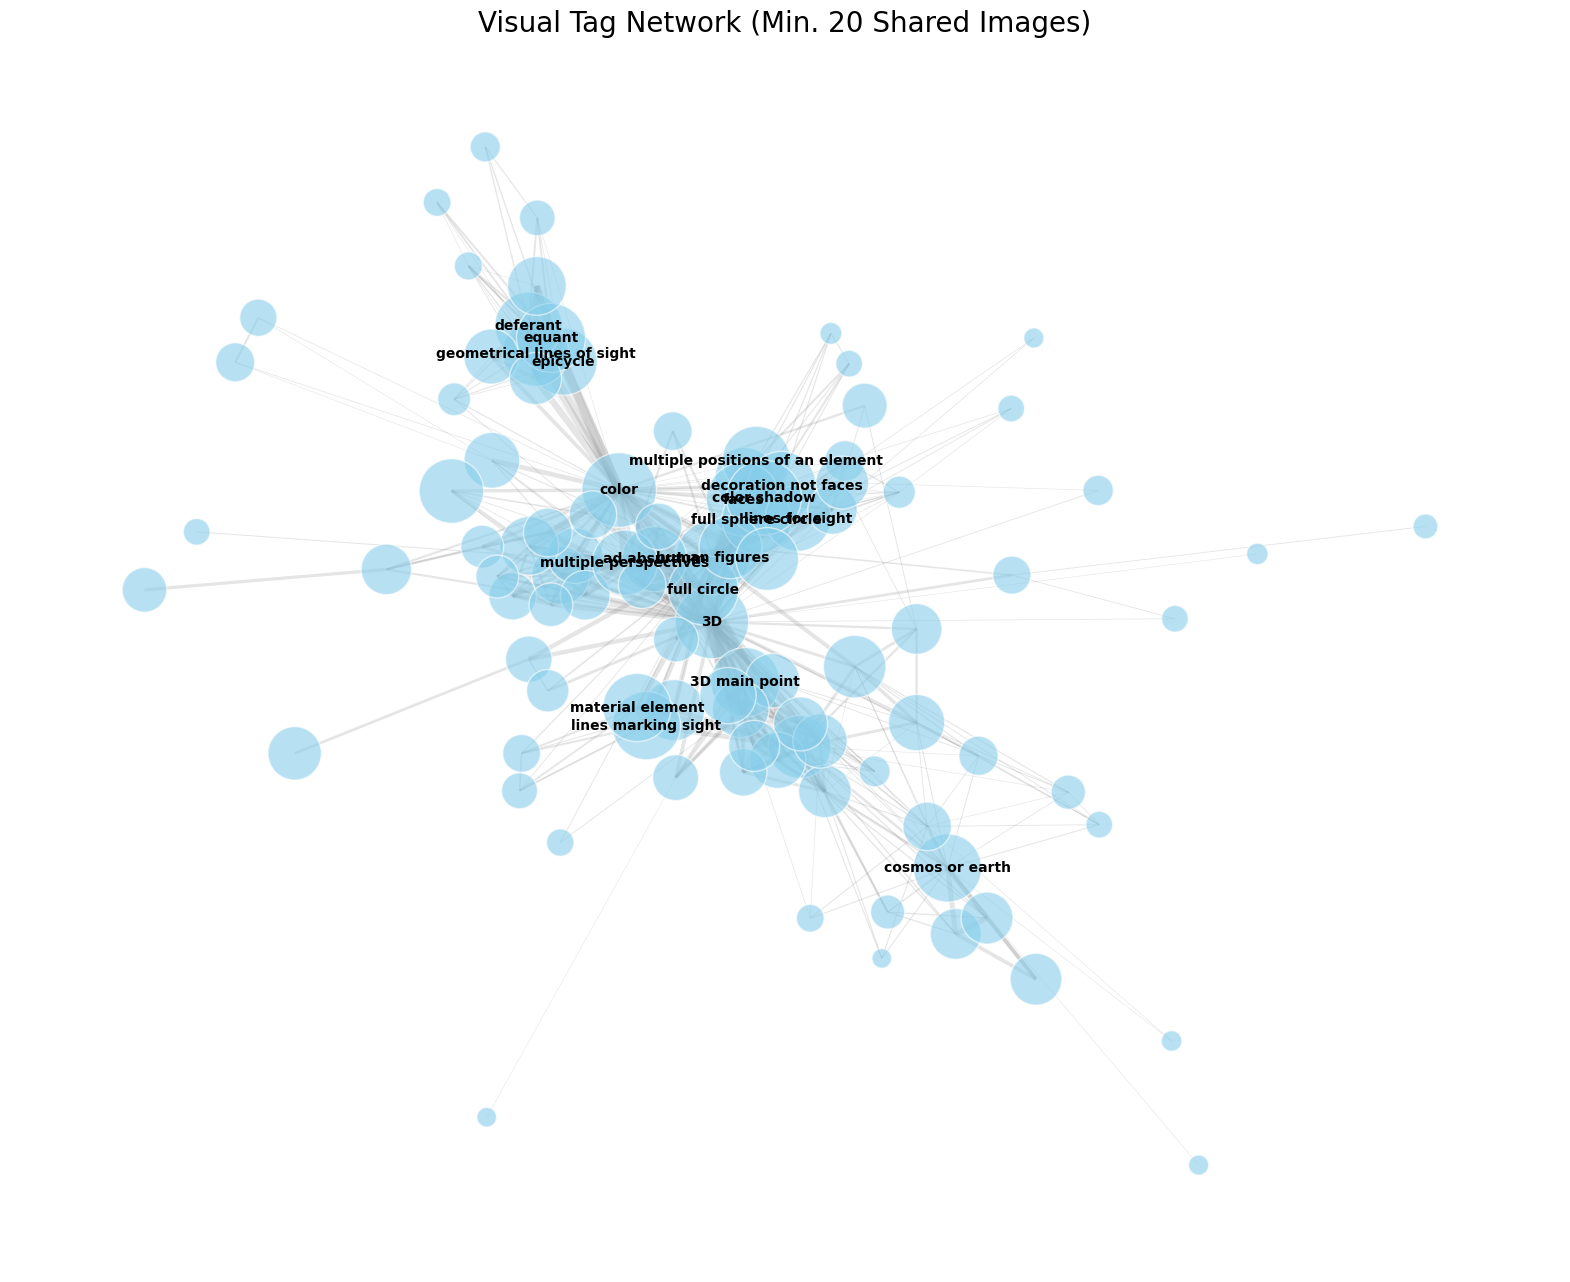

In [98]:
# Step 6: Visualize the network
MIN_WEIGHT = 20  # Only show stronger connections
TOP_TAGS_COUNT = 20 # Label only top tags

filtered_edges = edges_df[edges_df['weight'] >= MIN_WEIGHT]

G = nx.Graph()
for _, row in filtered_edges.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)

node_sizes = [tag_overview[tag_overview['tag'] == node]['unique_book_count'].values[0] * 10 if node in tag_overview['tag'].values else 100 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.6, edgecolors='white')
top_tags = tag_overview.head(TOP_TAGS_COUNT)['tag'].tolist()
labels = {node: node for node in G.nodes() if node in top_tags}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')
weights = [G[u][v]['weight'] / 50 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.2)

plt.title(f"Visual Tag Network (Min. {MIN_WEIGHT} Shared Images)", fontsize=20)
plt.axis('off')
plt.show()

## Categorical Time Series Analysis

In this section, we categorize all visual tags into six high-level groups and track the number of unique images containing tags from each category over 20-year intervals.

In [99]:
# Mapping tags to high-level categories
category_map = {
    'Spatial effects': [
        '3D', '3D main point', 'three-dimensionality effect', 'color shadow', 
        'lines conturing shadow', 'double lines for materiality effect'
    ],
    'Decoration': [
        'face', 'decoration not face', 'faces', 'face or figure', 
        'decoration', 'decoration not faces', 'decorative faces', 'decoration or face'
    ],
    'Human figures': [
        'human figure', 'human figures'
    ],
    'Perspectives and motion': [
        'multiple perspectives', 'multiple perspectives and or moments', 'perspective from earth', 
        'multiple positions of an element', 'time', 'multiple moments', 
        'multiple moments in one no', 'double images like comics', 'double image two perspectives', 
        'double image', 'double images', 'motion of the sun two dimensional rep curved line', 
        'motion of the sun two dimensional rep straight line'
    ],
    'Symbols': [
        'sign symbol', 'sign symbols', 'signs symbols', 'sign figure', 
        'moon symbol or dragon points', 'sun in sign no circles', 'multiple subjects sun and moon'
    ],
    'Diagram': [
        'diagram', 'diagram lines', 'diagram_fivezones', 'diagram_geo'
    ],
    'Ad Absurdum': [
        'ad absurdum'
    ],
    'Sight Lines': [
        'lines marking sight', 'lines representing sight', 'lines showing sight', 
        'geometrical lines of sight', 'lines for sight'
    ]
}

# Reverse mapping for easy lookup
tag_to_cat = {tag: cat for cat, tags in category_map.items() for tag in tags}

# Apply category to merged_df
merged_df['category'] = merged_df['tag'].map(tag_to_cat).fillna('Other')


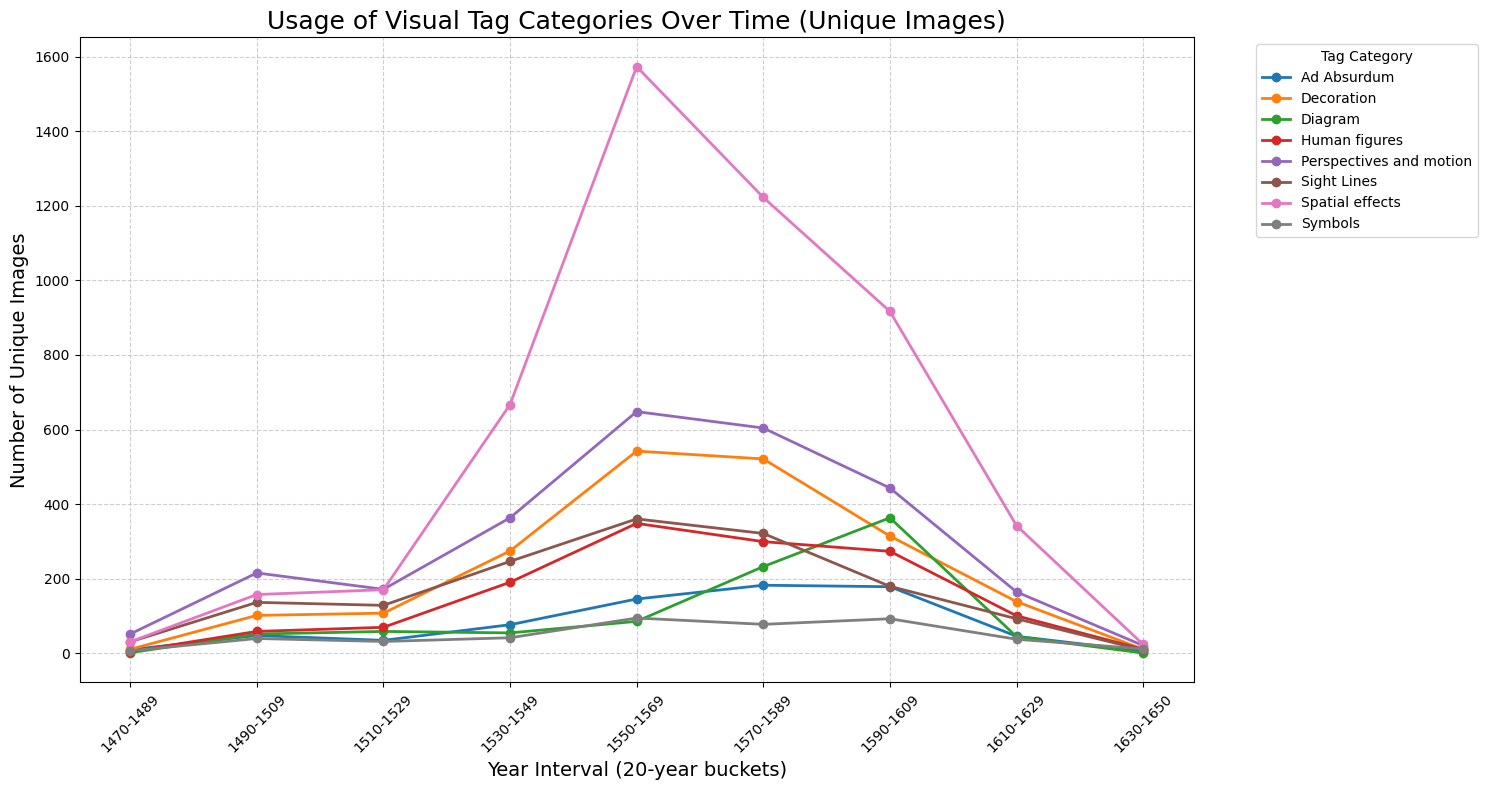

In [100]:
# Step 7: Time Series Data Generation
time_series = (
    merged_df.groupby(['year_interval', 'category'])['images']
    .nunique()
    .reset_index()
    .pivot(index='year_interval', columns='category', values='images')
    .fillna(0)
)

# Remove 'Other' category if requested to focus only on main categories
if 'Other' in time_series.columns:
    time_series = time_series.drop(columns=['Other'])

# Sorting the intervals correctly if needed (they are strings like 1470-1489)
time_series = time_series.sort_index()

# Plotting
plt.figure(figsize=(15, 8))
for column in time_series.columns:
    plt.plot(time_series.index, time_series[column], marker='o', label=column, linewidth=2)

plt.title("Usage of Visual Tag Categories Over Time (Unique Images)", fontsize=18)
plt.xlabel("Year Interval (20-year buckets)", fontsize=14)
plt.ylabel("Number of Unique Images", fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="Tag Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/visual_overall_counts.png', dpi=300)


plt.show()


In [101]:
# Code to list all unique visual tags found in the source Excel files
import os
import pandas as pd

tags_folder = "/Users/nogashlomi/projects/Image_data/visual_tags/"
all_found_tags = set()
for file in os.listdir(tags_folder):
    if file.endswith(".xlsx") or file.endswith(".xls"):
        try:
            df_temp = pd.read_excel(os.path.join(tags_folder, file))
            tag_cols = [col for col in df_temp.columns if col != "cluster_name"]
            for idx, row in df_temp.iterrows():
                for tag in tag_cols:
                    val = str(row[tag]).strip().lower()
                    if val == "yes" or val == "y" or val == "1":
                        all_found_tags.add(str(tag).strip())
        except: continue

sorted_tags = sorted(list(all_found_tags))
print(f"Total unique tags with values (yes/y/1): {len(sorted_tags)}")
for t in sorted_tags:
    print(t)

Total unique tags with values (yes/y/1): 117
3D
3D decoration
3D decoration_fivezones
3D main idea
3D main point
3D_fivezones
3D_geo
Multiple horizons
ad absurdum
advanced diagram
armilary sphere handle
circle general shape
color
color shadow
cosmos or earth
decorated
decorated or stars, tail, scales
decoration
decoration not faces
decoration of earth and water
decoration or face
decorative faces
decorative-info
decortion not terraqueous
deferant
diagram
diagram lines
diagram_fivezones
diagram_geo
direction of map up side down
disproportional decorative elements
disproportional element
double
double image
double image two perspectives
double images
double images like comics
double lines for materiality effect
earth and cosmos
element and not full circle
eliptic not round
epicycle
equant
eye
eye figure
face
face or figure
faces
figurative coin or other material object
five zones
full circle
full sphere circle
full terraqueous globe
geometrical lines of sight
human figure
human figures
h

In [102]:
# Categorizing books by Spatial vs Diagram presence
book_analysis = merged_df.groupby(["book", "year_interval"])["category"].unique().reset_index()

def categorize_exclusivity(cats):
    has_s = "Spatial effects" in cats
    has_d = "Diagram" in cats
    if has_s and has_d: return "Both"
    if has_s: return "Spatial Only"
    if has_d: return "Diagram Only"
    return "Other Categories"

book_analysis["exclusivity"] = book_analysis["category"].apply(categorize_exclusivity)

# Remove "Other Categories" for this specific focus
focal_books = book_analysis[book_analysis["exclusivity"] != "Other Categories"].copy()
print(f"Total unique books in focus: {len(focal_books)}")

Total unique books in focus: 314


In [103]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

counts = focal_books["exclusivity"].value_counts()
s_only = counts.get("Spatial Only", 0)
d_only = counts.get("Diagram Only", 0)
both = counts.get("Both", 0)

plt.figure(figsize=(10, 8))
v = venn2(subsets=(s_only, d_only, both), set_labels=("Spatial effects", "Diagram"))
plt.title("Exclusivity of Spatial vs Diagram Tags at Book Level", fontsize=16)
plt.show()

ModuleNotFoundError: No module named 'matplotlib_venn'

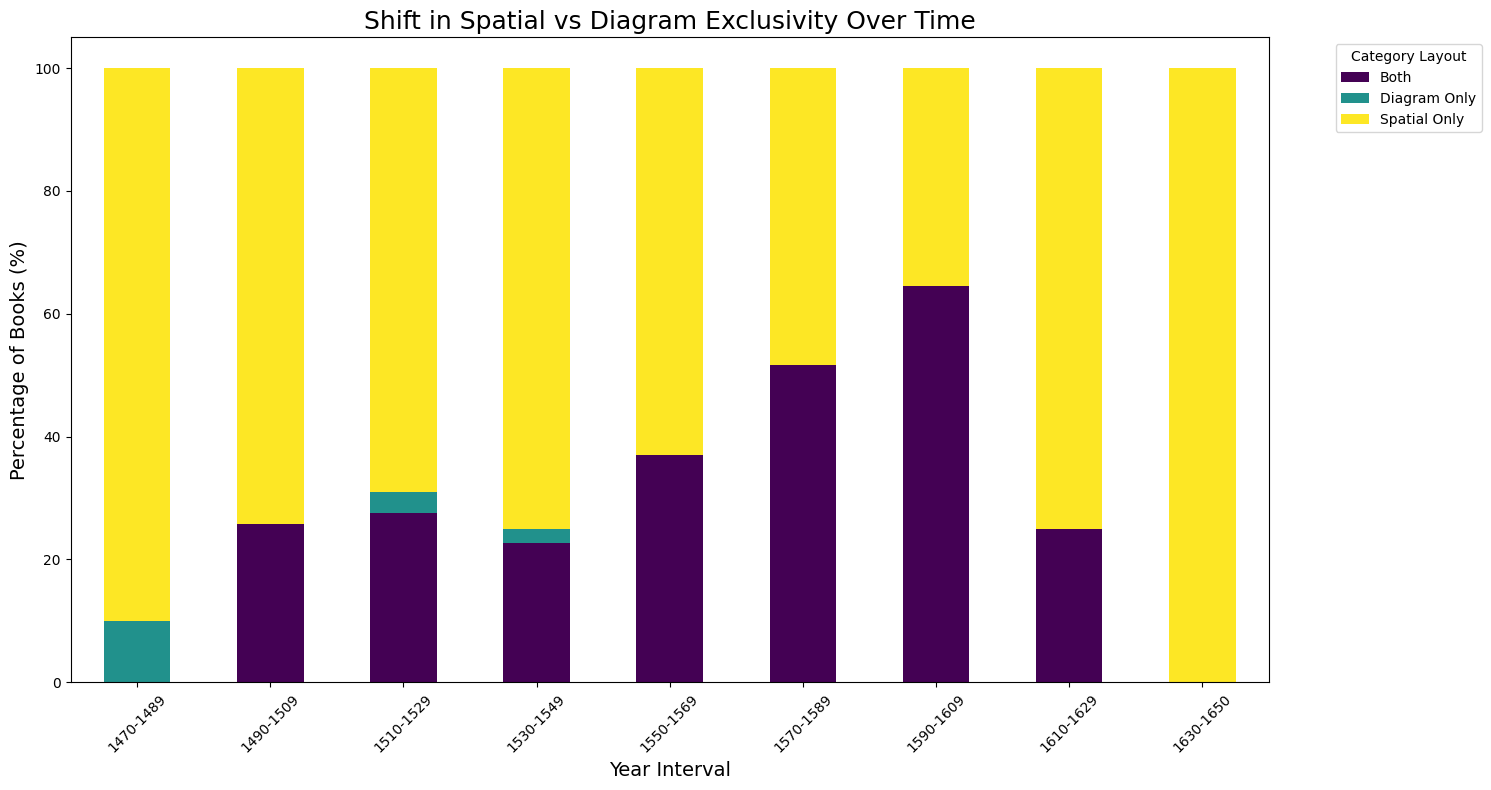

In [104]:
# Grouping by interval and exclusivity
temporal_excl = focal_books.groupby(["year_interval", "exclusivity"]).size().unstack(fill_value=0)

# Sorting and normalizing to 100%
temporal_excl = temporal_excl.sort_index()
temporal_excl_norm = temporal_excl.div(temporal_excl.sum(axis=1), axis=0) * 100

# Plotting
temporal_excl_norm.plot(kind="bar", stacked=True, figsize=(15, 8), colormap="viridis")

plt.title("Shift in Spatial vs Diagram Exclusivity Over Time", fontsize=18)
plt.xlabel("Year Interval", fontsize=14)
plt.ylabel("Percentage of Books (%)", fontsize=14)
plt.legend(title="Category Layout", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/diagrams_in_figurative.png', dpi=300)

plt.show()

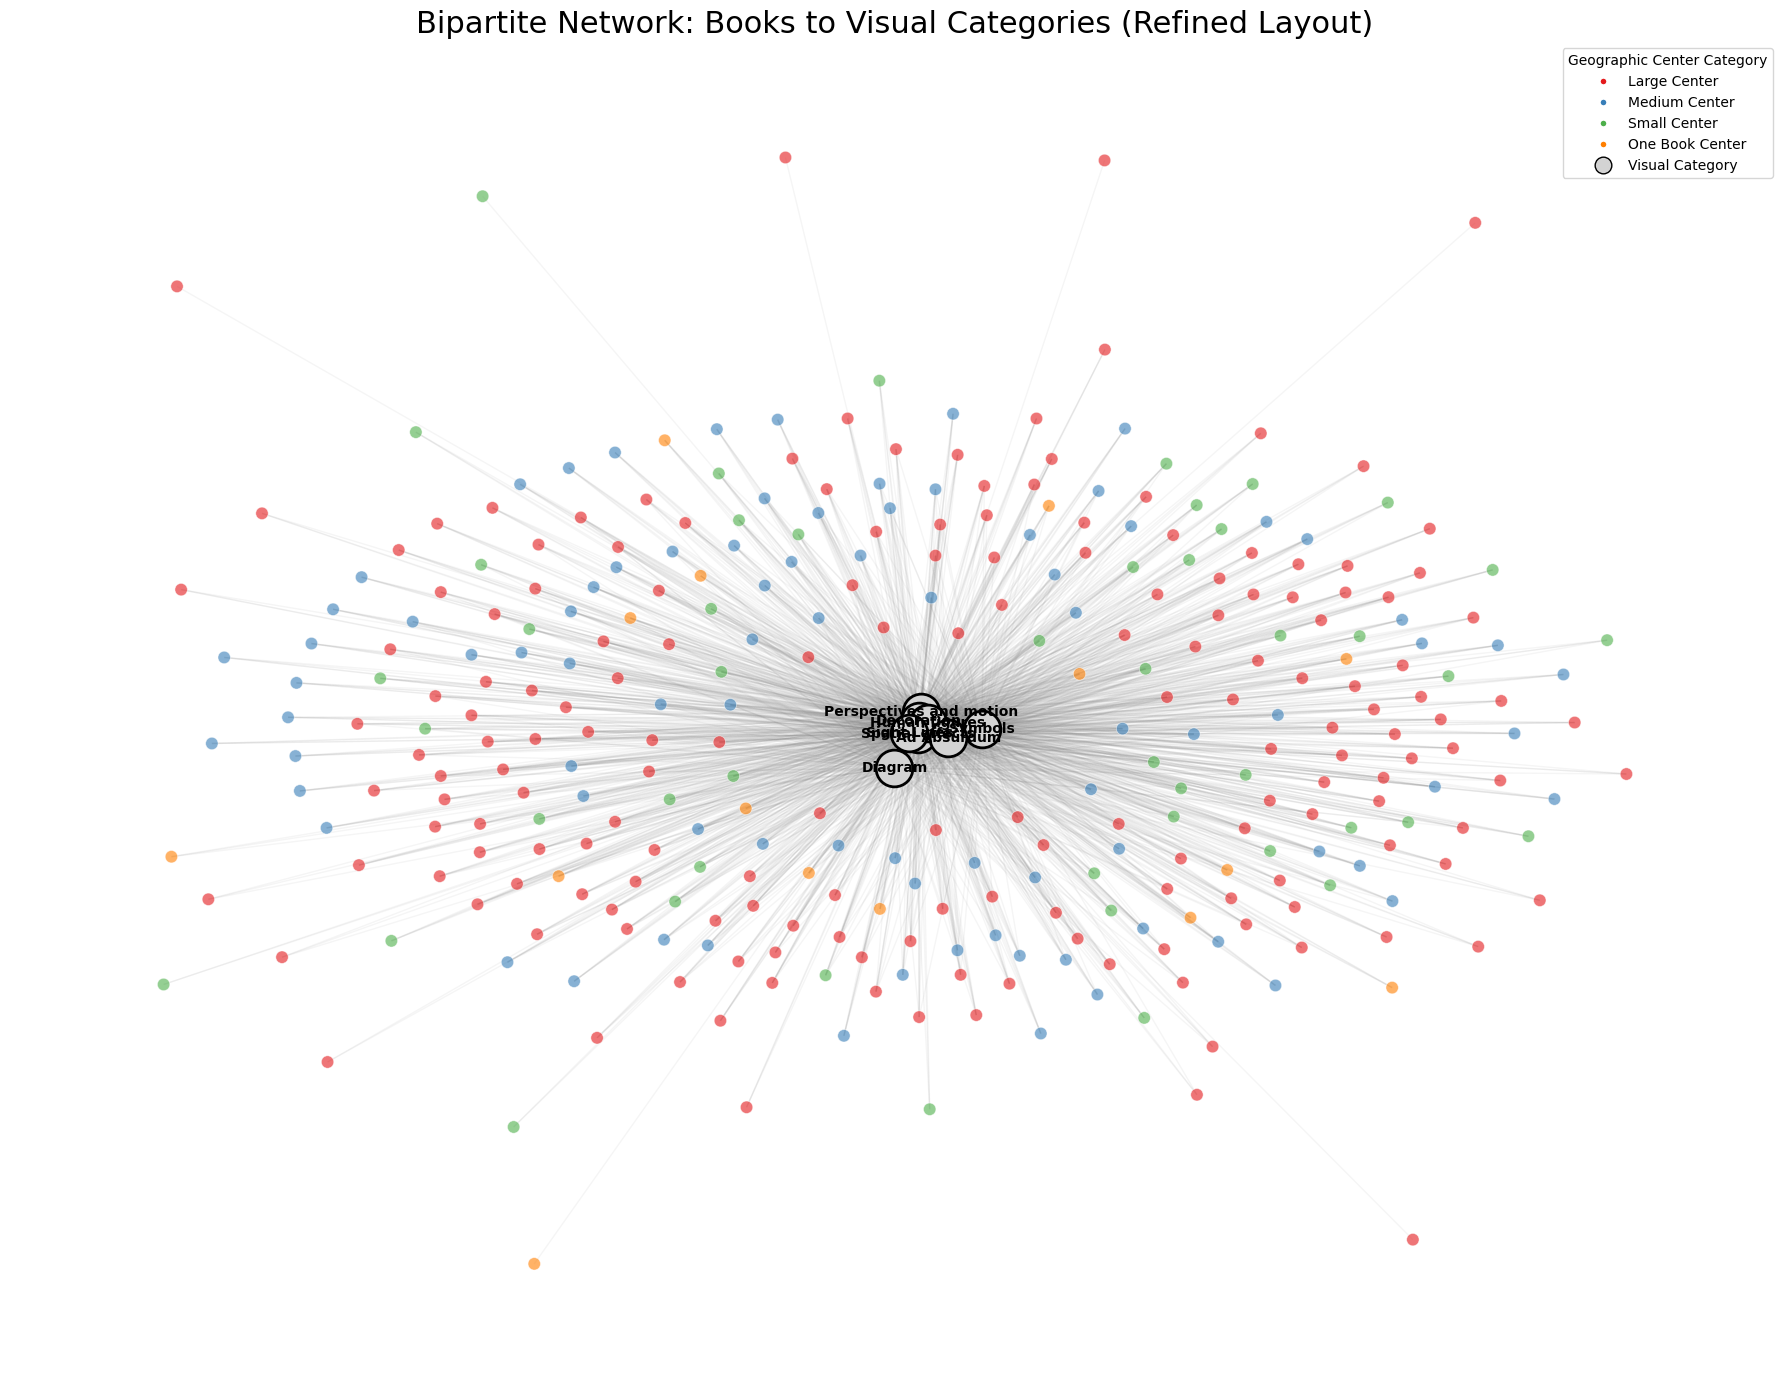

In [111]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Prepare Data
df_bip = merged_df[merged_df["category"] != "Other"].copy()

# Create Graph
B = nx.Graph()
books = df_bip["book"].unique()
categories = df_bip["category"].unique()

B.add_nodes_from(books, bipartite=0)
B.add_nodes_from(categories, bipartite=1)

edges = df_bip[["book", "category"]].drop_duplicates()
B.add_edges_from(zip(edges["book"], edges["category"]))

# 2. Color Mapping for Books
book_to_place = df_bip.set_index("book")["place_category"].to_dict()
color_map_dict = {
    "Large Center": "#e41a1c", 
    "Medium Center": "#377eb8", 
    "Small Center": "#4daf4a", 
    "One Book Center": "#ff7f00"
}

# 3. ADVANCED LAYOUT SETTINGS
plt.figure(figsize=(24, 18))  # Expanded figure size for extreme separation

# TEACHING MOMENT: 
# k: Optimal distance between nodes. High k (1.5+) pushes nodes far apart.
# iterations: Number of cycles for the physics model. Higher (200+) gives a cleaner result.
# scale: The radius of the layout universe.
pos = nx.spring_layout(B, k=1.8, iterations=250, seed=42, scale=10)

# Draw Book Nodes
book_colors = [color_map_dict.get(book_to_place.get(n, "grey"), "grey") for n in books]
nx.draw_networkx_nodes(B, pos, 
                       nodelist=books, 
                       node_color=book_colors, 
                       node_size=120,    # Increased for visibility
                       alpha=0.5,
                       edgecolors="white", 
                       linewidths=0.5)

# Draw Category Nodes
nx.draw_networkx_nodes(B, pos, 
                       nodelist=categories, 
                       node_color="lightgrey", 
                       node_size=3000,   # Large enough to hold text
                       edgecolors="black", 
                       linewidths=3)

# Draw Edges (Very subtle background wires)
nx.draw_networkx_edges(B, pos, alpha=0.04, edge_color="grey", width=0.5)

# Draw Labels for Categories
cat_labels = {c: c for c in categories}
nx.draw_networkx_labels(B, pos, labels=cat_labels, font_size=18, font_weight="bold", 
                        font_family="sans-serif", verticalalignment="center")

# Legend
legend_elements = [Line2D([0], [0], marker="o", color="w", label=k, 
                          markerfacecolor=v, markersize=15) for k, v in color_map_dict.items()]
legend_elements.append(Line2D([0], [0], marker="o", color="w", label="Visual Category", 
                             markerfacecolor="lightgrey", markersize=18, markeredgecolor="black"))

plt.legend(handles=legend_elements, loc="upper right", title="Geographic Categories", fontsize=14)
plt.title("Extreme Spaced Bipartite Network: Books to Visual Categories", fontsize=28)
plt.axis("off")
plt.tight_layout()
plt.show()